# <font color='blue'> The Monte Carlo Method </font>

In *Statistical Data Analysis*, Glen Cowan defines the Monte Carlo (MC) method as a numerical technique that uses random sampling to solve deterministic problems—most notably complex integration and statistical inference. It is rooted in the **Law of Large Numbers**, where the average result of random trials converges to the expected value.

---

## <font color='orange'> 1. Generating Random Variables </font>
All MC simulations rely on generating independent, uniform random variables $u$ distributed over the interval $[0, 1]$. To sample from more complex distributions $f(x)$, we use transformation methods.



### <font color='violet'> Key Transformation Techniques: </font>
* **The Transform Method (Inverse CDF):** If you have a cumulative distribution function (CDF) $F(x)$, then $x = F^{-1}(u)$ follows the desired probability density function $f(x)$.
* **The Acceptance-Rejection Method:** Used when the inverse CDF is unavailable. You enclose $f(x)$ within a simpler "proposal" distribution $g(x)$ scaled by a constant $c$. You sample from $g(x)$ and accept the result only if it falls below the target curve $f(x)$.

---

## <font color='orange'> 2. Monte Carlo Integration </font>
Cowan demonstrates that MC is a powerful tool for solving multidimensional integrals that are otherwise analytically impossible.

Given the integral:
$$I = \int_a^b f(x) dx$$

We express this as an expectation value by defining a uniform probability density $p(x) = \frac{1}{b-a}$:
$$I = (b-a) \int_a^b f(x) p(x) dx = (b-a) E[f(x)]$$

By drawing $N$ random samples $x_i$ over the interval $[a, b]$, the estimate is:
$$\hat{I} = \frac{b-a}{N} \sum_{i=1}^{N} f(x_i)$$



> **Note on Uncertainty:** The standard deviation of the Monte Carlo estimate shrinks by a factor of $1/\sqrt{N}$. Precision increases slowly, but the method is largely insensitive to the "curse of dimensionality."

---

## <font color='orange'> 3. Applications </font>

| Application | Utility |
| :--- | :--- |
| **Detector Simulation** | Modeling particle detector responses (geometry, material properties). |
| **Normalization Constants** | Calculating multidimensional integrals for evidence in Bayesian statistics. |
| **System Modeling** | Simulating stochastic systems without closed-form analytical solutions. |
| **Optimization** | Using Markov Chain Monte Carlo (MCMC) to explore complex parameter spaces. |

---

## <font color='orange'> Key Characteristics </font>
1. **Convergence:** Accuracy improves with $\frac{1}{\sqrt{N}}$; higher precision is computationally expensive.
2. **Dimension Independence:** Unlike grid-based integration, MC error does not grow exponentially with the number of dimensions.
3. **Parallelization:** Because samples are independent, MC simulations can be distributed across massive computing clusters with near-linear speedup.

### <font color='violet'> Example 1 : 1D </font>
#### Estimate the following integral:
$$I = \int_{0}^{1} e^{-x^2} \sin(10x) \, dx$$

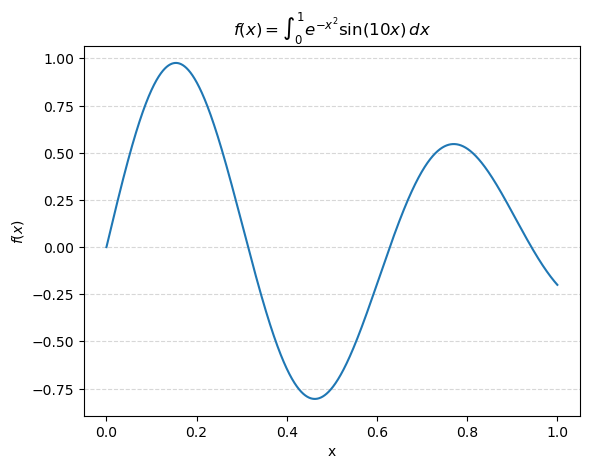

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(123)

x = np.arange(0,1,0.0001)
y = np.exp(-x*x)*np.sin(10*x)

plt.plot(x, y)
plt.title(rf"$f(x) = \int_{{0}}^{{1}} e^{{-x^2}} \sin(10x) \, dx$")
plt.xlabel('x')
plt.ylabel(rf"$f(x)$")
plt.grid(axis='y', linestyle='--' ,alpha=0.5)

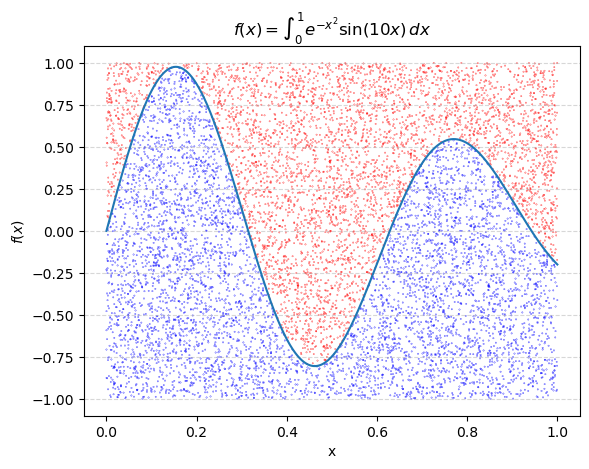

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(123)

x = np.arange(0,1,0.0001)
y = np.exp(-x*x)*np.sin(10*x)

x_rnd = np.random.uniform(0,1,10000)
y_rnd = np.random.uniform(-1,1,10000)
y_rnd_cal = np.exp(-x_rnd*x_rnd)*np.sin(10*x_rnd)

colors = np.where((y_rnd - y_rnd_cal) > 0, 'red', 'blue')

plt.plot(x, y)
plt.scatter(x_rnd, y_rnd, c=colors, s=0.05)
    
plt.title(rf"$f(x) = \int_{{0}}^{{1}} e^{{-x^2}} \sin(10x) \, dx$")
plt.xlabel('x')
plt.ylabel(rf"$f(x)$")
plt.grid(axis='y', linestyle='--' ,alpha=0.5)
plt.show()

In [61]:
# now to calculate the integral we only need to know what fraction of total dots lie in the blue region.

print(f"Total number of elements = {x_rnd.size}")

print(f"Number of elements in the red zone = {((y_rnd - y_rnd_cal) > 0).sum()}")
print(f"Number of elements in the blue zone = {x_rnd.size - ((y_rnd - y_rnd_cal) > 0).sum()}")

# fraction of elements in red zone
frac_area = ((y_rnd - y_rnd_cal) > 0).sum()/x_rnd.size
print(frac_area)

# area  of blue dots = total_area*frac_area
area_under_curve = frac_area*(2.0*1.0)
print(f"Area under the curve = {area_under_curve}")

Total number of elements = 10000
Number of elements in the red zone = 4303
Number of elements in the blue zone = 5697
0.4303
Area under the curve = 0.8606


### <font color='violet'> Example 2: 3D </font>
#### Estimate the following 3D Gaussian integral:  
$$I = \int_{-1}^{1} \int_{-1}^{1} \int_{-1}^{1} e^{-(x^2 + y^2 + z^2)} \, dx \, dy \, dz$$

In [62]:
import numpy as np

def f(x, y, z):
    # The function e^-(x^2 + y^2 + z^2)
    return np.exp(-(x**2 + y**2 + z**2))

N = 1_000_000 # Number of samples
# Generate random points within the bounds [-1, 1] for x, y, and z
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)
z = np.random.uniform(-1, 1, N)

# Calculate volume of the integration region
# (x_max - x_min) * (y_max - y_min) * (z_max - z_min)
volume = 2 * 2 * 2 

# The MC Estimator: (Volume / N) * sum(f(x, y, z))
integral_estimate = (volume / N) * np.sum(f(x, y, z))

print(f"Estimated Integral: {integral_estimate}")

Estimated Integral: 3.33477344097615


# <font color='blue'> Markov Chain Monte Carlo (MCMC) </font>

In data analysis, we often encounter a target distribution (like the "posterior" in Bayesian analysis) that is very hard to sample from directly. MCMC allows us to "explore" this distribution by performing a random walk that spends more time in areas of higher probability.



## <font color='orange'> The Practice Task: Metropolis-Hastings Algorithm </font>

We will use the Metropolis-Hastings algorithm to sample from a Gaussian distribution ($f(x) \propto e^{-x^2/2}$) without using a built-in normal distribution generator. We teach the computer to recognize the shape of the curve by only providing the probability density at any point $x$.

### <font color='orange'> The Algorithm Rules </font>

1.  **Start:** Pick an arbitrary starting point $x$.
2.  **Propose:** "Jump" to a new point $x'$ (usually $x' = x + \epsilon$, where $\epsilon$ is random noise).
3.  **Evaluate:** Calculate the ratio of the target probabilities:
    $$\alpha = \frac{f(x')}{f(x)}$$
4.  **Decide:**
    * If $\alpha \geq 1$ (the new point is more likely), **accept** the jump.
    * If $\alpha < 1$ (the new point is less likely), **accept** it with probability $\alpha$. Otherwise, stay at $x$.

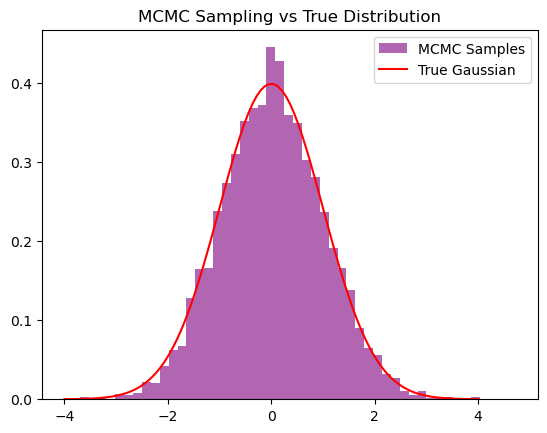

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the target function (unnormalized Gaussian)
def target_distribution(x):
    return np.exp(-x**2 / 2)

# 2. MCMC Parameters
n_samples = 10000
current_x = 0  # Starting point
samples = []

# 3. Metropolis-Hastings loop
for i in range(n_samples):
    # Propose a new move (a small jump)
    proposal_x = current_x + np.random.normal(0, 1)
    
    # Calculate acceptance probability
    prob_current = target_distribution(current_x)
    prob_proposal = target_distribution(proposal_x)
    alpha = prob_proposal / prob_current
    
    # Decide whether to accept
    if np.random.rand() < alpha:
        current_x = proposal_x
        
    samples.append(current_x)

# 4. Visualization
plt.hist(samples, bins=50, density=True, color='purple', alpha=0.6, label='MCMC Samples')
x_plot = np.linspace(-4, 4, 100)
plt.plot(x_plot, 1/np.sqrt(2*np.pi) * np.exp(-x_plot**2/2), 'r-', label='True Gaussian')
plt.legend()
plt.title("MCMC Sampling vs True Distribution")
plt.show()

# <font color='blue'> Applications of Markov Chain Monte Carlo (MCMC) </font>

Markov Chain Monte Carlo (MCMC) is one of the most powerful computational methods in statistics and physics. It is used whenever you need to sample from a probability distribution that is too complicated to sample from directly.

The key idea is simple:
* **A Markov chain** generates a sequence of samples.
* **Convergence:** The chain is constructed so that, after many steps, the samples follow the target probability distribution.
* **Approximation:** Rather than calculating difficult integrals analytically, MCMC approximates them by averaging over these samples.

---

## <font color='orange'> 1. Bayesian Statistics </font>
This is by far the most common application. Suppose you have parameters $\theta=(\theta_1,\theta_2,\ldots,\theta_n)$ and data $D$. Bayes' theorem gives:

$$P(\theta|D) = \frac{P(D|\theta)P(\theta)}{P(D)}$$

Usually:
* $P(D|\theta)$ (likelihood) is easy to compute.
* $P(\theta|D)$ (posterior) is impossible to normalize because $P(D) = \int P(D|\theta)P(\theta)d\theta$ is an enormous multidimensional integral.

MCMC avoids computing this integral altogether. Instead, it produces samples distributed according to $P(\theta|D)$, allowing you to estimate:
* Parameter means
* Uncertainties
* Correlations
* Credible intervals

## <font color='orange'> 2. Particle Physics </font>
Examples include:
* **Parameter estimation:** Fitting Higgs mass, signal strength, and nuisance parameters with hundreds of correlated parameters. Instead of minimizing a likelihood only once, MCMC explores the entire posterior.
* **Uncertainty estimation:** MCMC naturally propagates all uncertainties and correlations when you measure values like $\mu=1.02\pm0.08$.
* **Profile likelihood comparison:** Used to compare with frequentist fits or perform Bayesian inference.

## <font color='orange'> 3. Machine Learning </font>
Many probabilistic models have distributions that cannot be integrated analytically.
Examples:
* Bayesian neural networks
* Gaussian processes
* Latent variable models

Instead of finding one best parameter set, MCMC explores many likely parameter values.

## <font color='orange'> 4. Computational Physics </font>
Suppose you want to calculate the expectation value:

$$\langle A\rangle = \frac{\int A(x)e^{-E(x)/kT}dx}{\int e^{-E(x)/kT}dx}$$

This integral is impossible in high dimensions. MCMC samples configurations with probability $P(x) \propto e^{-E(x)/kT}$, then:

$$\langle A\rangle \approx \frac{1}{N}\sum_i A(x_i)$$

Applications include the Ising model, spin systems, lattice QCD, and condensed matter physics.

## <font color='orange'> 5. Other Key Applications </font>
* **Chemistry:** Protein folding, molecular dynamics, free-energy calculations, and drug design.
* **Finance:** Stochastic volatility models, risk models, and Bayesian portfolio optimization.
* **Robotics:** Estimating $P(\text{position}|\text{sensor data})$ when many possible locations exist.
* **Computer Vision:** Image reconstruction, segmentation, denoising, and object recognition.
* **Genetics:** Phylogenetic trees, population genetics, and genome inference.

---

## <font color='orange'> Why not just use ordinary Monte Carlo? </font>
Ordinary Monte Carlo requires independent samples. If you don't know how to sample from a target distribution directly, it is difficult or impossible.

MCMC instead performs a random walk:
$$x_1 \to x_2 \to x_3 \to x_4 \to x_5$$
where each point depends only on the previous one (the Markov property). Eventually, the points become distributed exactly like the target distribution.

## <font color='orange'> Common MCMC Algorithms </font>

| Algorithm | Main idea | Typical use |
| :--- | :--- | :--- |
| **Metropolis** | Accept/reject random proposals | Simple distributions |
| **Metropolis–Hastings** | Generalizes Metropolis with asymmetric proposals | General Bayesian inference |
| **Gibbs Sampling** | Sample one parameter at a time from its conditional distribution | Hierarchical models |
| **Hamiltonian Monte Carlo (HMC)** | Uses gradients to propose efficient moves | High-dimensional problems |
| **No-U-Turn Sampler (NUTS)** | Adaptive version of HMC | Modern Bayesian software (e.g., Stan, PyMC) |
| **Slice Sampling** | Samples uniformly under the density curve | Distributions with awkward shapes |

## <font color='orange'> Why MCMC is powerful </font>
Imagine fitting a model with 100 parameters. Evaluating the posterior on a grid with just 100 points per parameter would require $100^{100}$ evaluations—completely infeasible. 

MCMC avoids this **"curse of dimensionality"** by spending most of its time sampling regions of high posterior probability. Instead of exploring every possible parameter combination, it concentrates on the combinations that matter, making high-dimensional Bayesian inference practical.

For someone working in particle physics, MCMC is particularly valuable for Bayesian parameter estimation, propagating systematic uncertainties through complex models, and exploring high-dimensional likelihood or posterior surfaces where direct integration is impossible.